# Shear, Moment, and Deflection Diagrams — from a toy beam to a real bridge

Line-girder analysis in three passes, each building on the last:

1. **Toy example** — a three-span continuous beam, one section throughout:
   shear, moment, and deflection diagrams from `civilpy.structural.beam_bending`.
2. **A real bridge from Rhino** — read `REF-DESIGN.3dm` (authored with the ODOT
   Rhino plug-in's `GirderLines` / `GirderShape` commands) and run the same
   diagrams on its actual span arrangement, with the section transitions overlaid.
3. **HL-93 live load, without MDX** — the pure-Python influence-line envelope
   (`civilpy.structural.girder_pipeline`) that stands in for a commercial
   line-girder run, factored to Strength I and used to *size the girder sections*,
   compared against what the consultant's MDX analysis actually chose.
   A guarded template shows the equivalent MIDAS Civil NX pull.

Heads-up on runtime: the symbolic 4-span solve (§2) and the 41-station HL-93
envelope (§3) each take ~30–45 s.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from civilpy.structural.beam_bending import ContinuousBeam, DistributedLoadV
from civilpy.structural.steel import W

E_KSI = 29000.0  # structural steel

## 1&nbsp;&nbsp;Toy example — three equal spans, one section

Three 50 ft spans, W24X104 throughout, a uniform 2 klf load (think steel +
wet deck on an interior girder). `beam_bending.ContinuousBeam` solves the
statically-indeterminate reactions symbolically (compatibility: zero deflection
at each interior support), so the diagrams are exact.

Textbook check (AISC Table 3-23, three equal spans, uniform load):
* end reactions `0.4wL`, interior `1.1wL`
* max negative moment `-0.100 wL²` at the interior supports → **−500 kip·ft**
* max positive moment `0.080 wL²` in the end spans → **+400 kip·ft**

In [2]:
L, w = 50.0, 2.0   # ft, klf (down)

toy = ContinuousBeam(3 * L, intermediate_supports=[L, 2 * L])
toy.pinned_support = 0
toy.rolling_support = 3 * L
toy.add_loads([DistributedLoadV(w, (0, 3 * L))])   # positive = downward

_, r_end_a, r_end_b = toy.get_reaction_forces()
r_interior = (w * 3 * L - abs(r_end_a) - abs(r_end_b)) / 2  # statics + symmetry
print(f"end reactions:      {abs(r_end_a):.1f} kips   (0.4wL = {0.4*w*L:.1f})")
print(f"interior reactions: {r_interior:.1f} kips  (1.1wL = {1.1*w*L:.1f})")

end reactions:      40.0 kips   (0.4wL = 40.0)
interior reactions: 110.0 kips  (1.1wL = 110.0)


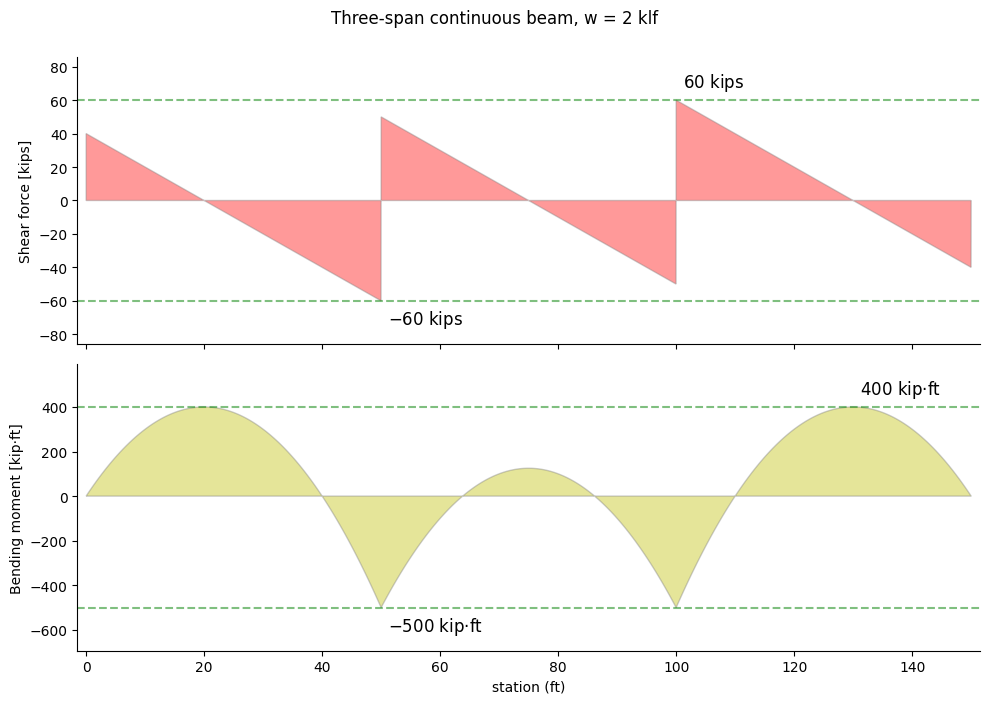

In [3]:
fig, (ax_v, ax_m) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
toy.plot_shear_force(ax=ax_v)
toy.plot_bending_moment(ax=ax_m)
ax_m.set_xlabel("station (ft)")
fig.suptitle("Three-span continuous beam, w = 2 klf", y=1.0)
fig.tight_layout()
plt.show()

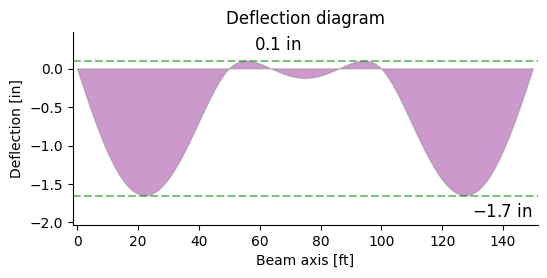

W24X104: Ix = 3100 in^4;  L/800 = 0.75 in per span (live-load limit, for scale)


In [4]:
# Deflection needs the actual section: E in ksi, I in in^4 -> result in inches.
w24x104 = W("W24X104")
Ix = float(w24x104.I_x.to("in**4").magnitude)

fig = toy.plot_deflection(E_KSI, Ix)
plt.show()
print(f"W24X104: Ix = {Ix:.0f} in^4;  L/800 = {L*12/800:.2f} in per span (live-load limit, for scale)")

## 2&nbsp;&nbsp;A real bridge, read from Rhino

`REF-DESIGN` — a four-span continuous steel unit (37.5 / 62.5 / 62.5 / 37.5 ft),
five girder lines at 7 ft, authored in Rhino with the plug-in and saved to
`res/Rhino 3dms/REF-DESIGN.3dm`. Each beamline is **one line of several curves**:
the curve breaks where the *section changes* (`gdr.shape` steps from W24X104 up
to W24X131 / W24X162 over the piers), not where the bearings sit.

`read_girder_model` turns the tagged file into the canonical `StructuralModel`
hub: one element chain per `gdr.line`, bearings as restraints — splitting any
element that a bearing lands on mid-length, since real authoring puts section
transitions near inflection points, not over piers.

> The file carries no `gdr.deck_t` / `gdr.deck_weff` (the loud warning below is
> the reader keeping that honest). We assume an 8.5 in structural slab from here
> on — replace with the plan value when you have it.

In [5]:
from civilpy.structural.rhino_gdr import read_girder_model

bridge = read_girder_model("res/Rhino 3dms/REF-DESIGN.3dm")
model = bridge.model

chain = bridge.girder_lines["1"]          # interior girder line
segs = pd.DataFrame(
    [(model.elements[e].section,
      model.nodes[model.elements[e].node_a].x,
      model.nodes[model.elements[e].node_b].x) for e in chain],
    columns=["section", "x0_ft", "x1_ft"])
segs["length_ft"] = segs.x1_ft - segs.x0_ft

supports = sorted(model.nodes[nid].x for nid in model.restraints
                  if model.nodes[nid].y == 0.0)
spans = np.diff(supports)
print("bearings at", [f"{s:.2f}" for s in supports], "ft  ->  spans",
      [f"{s:.1f}" for s in spans], "ft")
segs

bearings at ['0.21', '37.75', '100.25', '162.75', '200.71'] ft  ->  spans ['37.5', '62.5', '62.5', '38.0'] ft


/home/dane/projects/civilpy/src/civilpy/structural/rhino_gdr.py:419: UserWarning: girder model is missing gdr.deck_t and/or gdr.deck_weff -- the composite deck section cannot be built without them; supply the structural slab thickness (in) and effective width (in), or fall back to ODOT BDM defaults downstream (G5).
  warnings.warn(


,section,x0_ft,x1_ft,length_ft
0,W24X104,0.208333,24.041667,23.833333
1,W24X131,24.041667,37.750000,13.708333
2,W24X131,37.750000,49.208333,11.458333
3,W24X104,49.208333,84.791667,35.583333
4,W24X162,84.791667,100.250000,15.458333
5,W24X162,100.250000,116.125000,15.875000
6,W24X104,116.125000,151.708333,35.583333
7,W24X131,151.708333,162.750000,11.041667
8,W24X131,162.750000,176.875000,14.125000
9,W24X104,176.875000,200.708333,23.833333


In [6]:
# Section transitions = stations where adjacent chain elements change section
# (these are the field-splice candidates the GirderSplice discussion is about).
transitions = [float(segs.x1_ft[i]) for i in range(len(segs) - 1)
               if segs.section[i] != segs.section[i + 1]]
print("shape transitions at", [f"{t:.1f}" for t in transitions], "ft")

# Non-composite dead load on the interior line: length-weighted steel weight
# (+10% details), plus the wet 8.5 in slab on the 7 ft tributary width.
DECK_T_IN, SPACING_FT, N_GIRDERS = 8.5, 7.0, 5   # assumed slab; file had no gdr.deck_t
steel_klf = sum(row.length_ft * float(W(row.section).W.to("lbf/ft").magnitude)
                for row in segs.itertuples()) / (supports[-1] - supports[0]) / 1000.0
dc1 = steel_klf * 1.10 + SPACING_FT * DECK_T_IN / 12 * 0.150
print(f"steel {steel_klf:.3f} klf (avg)  ->  DC1 = {dc1:.3f} klf")

shape transitions at ['24.0', '49.2', '84.8', '116.1', '151.7', '176.9'] ft
steel 0.120 klf (avg)  ->  DC1 = 0.876 klf


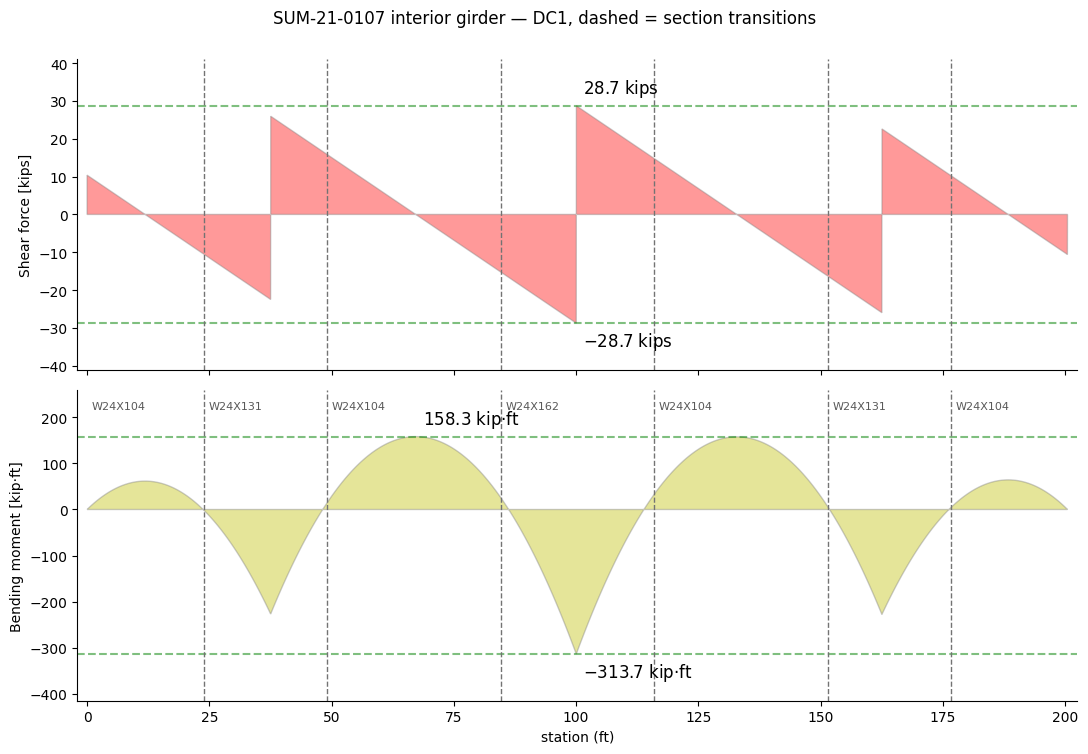

In [7]:
# Same three diagrams on the real span arrangement (~30 s symbolic solve).
x0 = supports[0]
real = ContinuousBeam(supports[-1] - x0,
                      intermediate_supports=[s - x0 for s in supports[1:-1]])
real.pinned_support = 0
real.rolling_support = supports[-1] - x0
real.add_loads([DistributedLoadV(dc1, (0, supports[-1] - x0))])  # positive = downward

fig, (ax_v, ax_m) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
real.plot_shear_force(ax=ax_v)
real.plot_bending_moment(ax=ax_m)
for ax in (ax_v, ax_m):
    for t in transitions:
        ax.axvline(t - x0, color="0.45", ls="--", lw=1)
for i, row in segs.iterrows():   # label each section run once
    if i == 0 or row.section != segs.section[i - 1]:
        ax_m.annotate(row.section, xy=(row.x0_ft - x0 + 1, 0.94),
                      xycoords=("data", "axes fraction"),
                      fontsize=8, color="0.35")
ax_m.set_xlabel("station (ft)")
fig.suptitle("REF-DESIGN interior girder — DC1, dashed = section transitions", y=1.0)
fig.tight_layout()
plt.show()

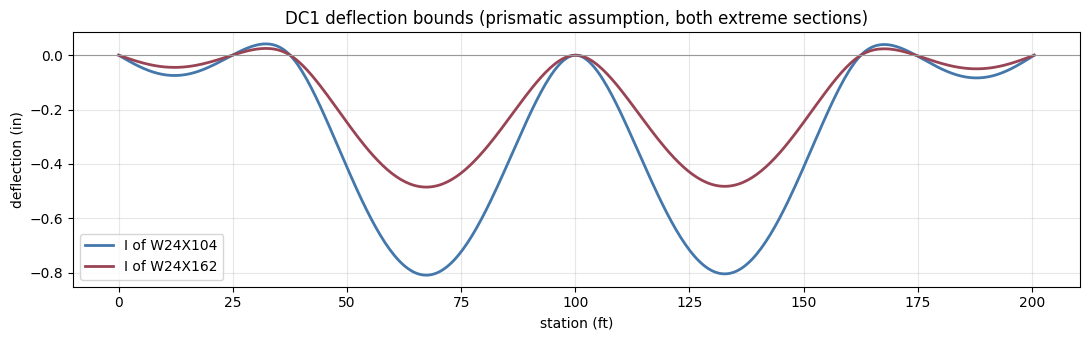

In [8]:
# Deflection under DC1. One caveat: beam_bending assumes a PRISMATIC member,
# so we bound the answer with the lightest and heaviest sections on the line.
fig, ax = plt.subplots(figsize=(11, 3.5))
from sympy import lambdify
xs = np.linspace(0, supports[-1] - x0, 400)
for label, color in (("W24X104", "#4477aa"), ("W24X162", "#994455")):
    Ii = float(W(label).I_x.to("in**4").magnitude)
    expr = real.get_deflection_function(E_KSI, Ii)      # symbolic delta(x)
    f = lambdify(list(expr.free_symbols)[0], expr, "numpy")
    ax.plot(xs, f(xs), color=color, lw=2, label=f"I of {label}")
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("station (ft)"); ax.set_ylabel("deflection (in)")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("DC1 deflection bounds (prismatic assumption, both extreme sections)")
plt.tight_layout(); plt.show()

## 3&nbsp;&nbsp;HL-93 live load — sizing the sections without MDX

The W24X104 / 131 / 162 pattern in the file came from a consultant's **MDX** run.
This section reproduces the sizing logic with civilpy alone:

1. **Influence lines** for moment at each station
   (`continuous_beam.ContinuousBeam.moment_influence_line`, slope-deflection).
2. **HL-93** per AASHTO 3.6.1.2 — design truck *or* tandem (whichever governs,
   +33 % IM) plus the 0.64 klf lane load on the adverse influence area
   (`girder_pipeline.hl93_pos_neg`).
3. **Distribution factor** for an interior girder, type (a) cross-section
   (`aashto.lrfd.distribution.moment_df_interior`).
4. **Strength I**: `Mu = 1.25·DC + 1.50·DW + 1.75·(LL+IM)`.
5. Required plastic modulus `Zx = Mu / (φf·Fy)` per station → lightest W24 that
   works → compare with the authored sections.

Assumptions kept loud: bare-steel plastic capacity (`φf = 1.0`, compact, fully
braced) — no composite action in positive flexure (conservative) and no
lateral-torsional buckling reduction in negative flexure (unconservative there;
the real negative-region pick also carries deflection, fatigue, and
constructibility. That is exactly the gap between this first pass and MDX).

In [9]:
from civilpy.structural.aashto.lrfd.distribution import (
    longitudinal_stiffness_kg, moment_df_interior)

base = W("W24X104")
e_g = float(base.depth.to("in").magnitude) / 2 + 1.0 + DECK_T_IN / 2  # haunch 1 in
kg = longitudinal_stiffness_kg(
    8.0,                                             # modular ratio n
    float(base.I_x.to("in**4").magnitude),
    float(base.A.to("in**2").magnitude),
    e_g)
mdf = moment_df_interior(s_ft=SPACING_FT, l_ft=float(max(spans)),
                         t_s=DECK_T_IN, k_g=kg, n_beams=N_GIRDERS)
print(f"Kg = {kg:,.0f} in^4   gdf = {mdf.governing:.3f} "
      f"(1-lane {mdf.one_lane:.3f} / multi {mdf.multi_lane:.3f})   "
      f"applicable: {mdf.applicable}")

Kg = 98,306 in^4   gdf = 0.535 (1-lane 0.397 / multi 0.535)   applicable: True


In [10]:
from civilpy.structural.girder_pipeline import girder_line_envelope

dc2 = 2 * 0.640 / N_GIRDERS      # two 42 in single-slope barriers, shared
dw = 0.060 * SPACING_FT          # FWS 0.060 ksf on the tributary width
print(f"DC1 {dc1:.3f} / DC2 {dc2:.3f} / DW {dw:.3f} klf,  gdf {mdf.governing:.3f}")

stations, moments = girder_line_envelope(     # ~40 s: 41 influence lines
    supports, dc1_klf=dc1, dc2_klf=dc2, dw_klf=dw,
    n_sections=41, gdf=mdf.governing)

DC1 0.876 / DC2 0.256 / DW 0.420 klf,  gdf 0.535


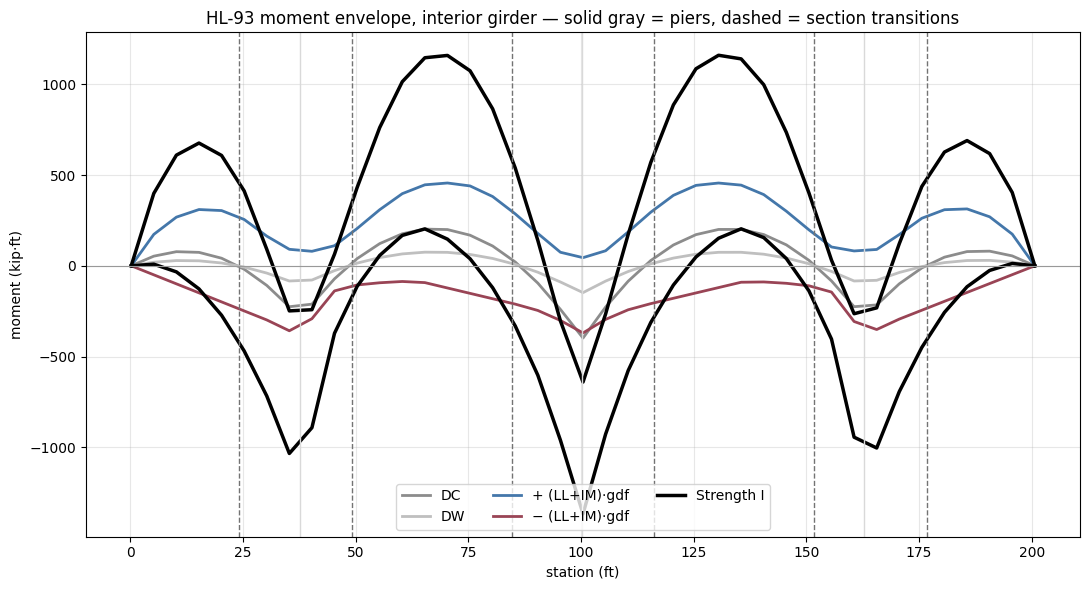

max +Mu 1159 kip·ft @ 131 ft;  min −Mu -1366 kip·ft @ 100 ft


In [11]:
dc = np.array(moments["dc1"]) + np.array(moments["dc2"])
dw_m = np.array(moments["dw"])
ll_pos, ll_neg = np.array(moments["ll_pos"]), np.array(moments["ll_neg"])
mu_pos = 1.25 * dc + 1.50 * dw_m + 1.75 * ll_pos
mu_neg = 1.25 * dc + 1.50 * dw_m + 1.75 * ll_neg
sta = np.array(stations)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(sta, dc, color="0.55", lw=2, label="DC")
ax.plot(sta, dw_m, color="0.75", lw=2, label="DW")
ax.plot(sta, ll_pos, color="#4477aa", lw=2, label="+ (LL+IM)·gdf")
ax.plot(sta, ll_neg, color="#994455", lw=2, label="− (LL+IM)·gdf")
ax.plot(sta, mu_pos, color="black", lw=2.5, label="Strength I")
ax.plot(sta, mu_neg, color="black", lw=2.5)
for s in supports[1:-1]:
    ax.axvline(s, color="0.85", lw=1)
for t in transitions:
    ax.axvline(t, color="0.45", ls="--", lw=1)
ax.axhline(0, color="0.6", lw=0.8)
ax.set_xlabel("station (ft)"); ax.set_ylabel("moment (kip·ft)")
ax.legend(ncol=3, loc="lower center"); ax.grid(alpha=0.3)
ax.set_title("HL-93 moment envelope, interior girder — solid gray = piers, dashed = section transitions")
plt.tight_layout(); plt.show()

print(f"max +Mu {mu_pos.max():.0f} kip·ft @ {sta[mu_pos.argmax()]:.0f} ft;  "
      f"min −Mu {mu_neg.min():.0f} kip·ft @ {sta[mu_neg.argmin()]:.0f} ft")

In [12]:
# Required Zx per station -> lightest W24 -> compare with the authored layout.
PHI_F, FY = 1.0, 50.0
z_req = np.maximum(np.abs(mu_pos), np.abs(mu_neg)) * 12.0 / (PHI_F * FY)

from civilpy.structural.steel import steel_tables
w24 = steel_tables[steel_tables.EDI_Std_Nomenclature.str.match(r"W24X\d+$", na=False)]
w24 = w24[["EDI_Std_Nomenclature", "W", "Zx"]].astype({"W": float, "Zx": float})
w24 = w24.sort_values("W")                      # lightest first

def lightest_w24(z):
    ok = w24[w24.Zx >= z]
    return ok.iloc[0].EDI_Std_Nomenclature if len(ok) else "(none)"

runs, row = [], None
for _, seg in segs.iterrows():                   # merge same-section runs
    if row is None or seg.section != row["authored"]:
        row = {"authored": seg.section, "x0": seg.x0_ft, "x1": seg.x1_ft}
        runs.append(row)
    row["x1"] = seg.x1_ft

for r in runs:
    in_run = (sta >= r["x0"] - 1e-6) & (sta <= r["x1"] + 1e-6)
    r["Zx_req"] = float(z_req[in_run].max())
    r["computed"] = lightest_w24(r["Zx_req"])
    r["Zx_authored"] = float(w24.set_index("EDI_Std_Nomenclature").Zx[r["authored"]])

comparison = pd.DataFrame(runs)[
    ["x0", "x1", "Zx_req", "computed", "authored", "Zx_authored"]].round(1)
comparison

,x0,x1,Zx_req,computed,authored,Zx_authored
0,0.2,24.0,162.2,W24X68,W24X104,289.0
1,24.0,49.2,248.0,W24X94,W24X131,370.0
2,49.2,84.8,278.0,W24X103,W24X104,289.0
3,84.8,116.1,327.8,W24X131,W24X162,468.0
4,116.1,151.7,278.3,W24X103,W24X104,289.0
5,151.7,176.9,240.8,W24X94,W24X131,370.0
6,176.9,200.7,165.5,W24X68,W24X104,289.0


The first-principles pass reproduces the *pattern* — heavier shapes over the
piers, W24X104 fine in the positive regions — and lands within one or two shape
sizes of MDX everywhere. Where it under-calls the authored section (the pier
regions), the difference is the physics this pass deliberately skips: LTB on the
discretely-braced bottom flange in negative flexure, live-load deflection,
fatigue at the transitions, and constructibility. Those checks live in
`civilpy.structural.aashto` and `girder_optimizer` — that refinement loop, not
the envelope itself, is what you are buying from MDX.

### The MIDAS path

The same envelope can come from a live MIDAS Civil NX model instead of the
Python influence lines — same downstream sizing code either way. Flip the guard
when MIDAS is listening (see the *MIDAS Bridge Model Walkthrough* notebook;
cached API results for three other bridges sit in `midas_func_results/`).

In [13]:
RUN_MIDAS = False   # requires MIDAS Civil NX with the API enabled

if RUN_MIDAS:
    from civilpy.structural.midas import MidasCivil
    from civilpy.structural.influence_lines import influence_line_from_midas

    midas = MidasCivil()                        # -> http://localhost:8080 by default
    midas.open("REF-DESIGN.mcb")
    il = influence_line_from_midas(midas, element=1,
                                   cases=[f"UNIT{i}" for i in range(1, 42)])
    print(il.hl93_effect(im=0.33, lane_klf=0.64))
else:
    print("RUN_MIDAS = False — using the pure-Python envelope above.")

RUN_MIDAS = False — using the pure-Python envelope above.


---
### Function cheat sheet

| Need | Call |
|---|---|
| Reactions / V / M / δ, one member | `beam_bending.ContinuousBeam` (+ `Cantilever…`, `FixedFixed…`) |
| Read a `gdr.*`-tagged Rhino model | `rhino_gdr.read_girder_model(path)` |
| Moment influence line, multi-span | `continuous_beam.ContinuousBeam.moment_influence_line(x)` |
| HL-93 ± effect for one IL | `girder_pipeline.hl93_pos_neg(il)` |
| Full per-case moment envelope | `girder_pipeline.girder_line_envelope(supports, …)` |
| Live-load distribution factors | `aashto.lrfd.distribution.moment_df_interior(…)` |
| Splice placement on the envelope | `girder_pipeline.place_splices(…)` |
| Girder + splice cost sweep | `girder_optimizer` |